In [2]:
import pandas as pd

df = pd.read_csv('../data/bikes_raw.csv')
df.head()

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha


In [3]:
print(df.shape)
print(df.columns.tolist())
df.info()

(32648, 8)
['bike_name', 'price', 'city', 'kms_driven', 'owner', 'age', 'power', 'brand']
<class 'pandas.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   32648 non-null  str    
 1   price       32648 non-null  float64
 2   city        32648 non-null  str    
 3   kms_driven  32648 non-null  float64
 4   owner       32648 non-null  str    
 5   age         32648 non-null  float64
 6   power       32648 non-null  float64
 7   brand       32648 non-null  str    
dtypes: float64(4), str(4)
memory usage: 3.4 MB


In [4]:
print("Duplicate rows:", df.duplicated().sum())
df.describe()

Duplicate rows: 25324


,price,kms_driven,age,power
count,3.264800e+04,32648.000000,32648.000000,32648.000000
mean,6.829542e+04,26344.625184,8.048211,213.511302
std,9.071860e+04,22208.527695,4.031700,134.428868
min,4.400000e+03,1.000000,1.000000,100.000000
25%,2.500000e+04,12000.000000,5.000000,150.000000
50%,4.300000e+04,20373.000000,7.000000,150.000000
75%,8.000000e+04,35000.000000,10.000000,220.000000
max,1.900000e+06,750000.000000,63.000000,1800.000000


In [5]:
df = df.drop_duplicates()
print(df.shape)

(7324, 8)


In [6]:
print(df[df['age'] > 30][['bike_name', 'age', 'price', 'kms_driven']])
print(df[df['kms_driven'] > 200000][['bike_name', 'age', 'kms_driven', 'price']])

                          bike_name   age     price  kms_driven
334     Royal Enfield Bullet 350 cc  39.0  125000.0     16500.0
1519              Rajdoot GTX 175cc  41.0   75000.0       500.0
2146    Royal Enfield‎ Bullet 350cc  37.0   85990.0     19000.0
2978    Royal Enfield‎ Bullet 350cc  43.0   95000.0     50000.0
2980    Royal Enfield‎ Bullet 350cc  43.0  135000.0     85000.0
5017            Yezdi Classic 250cc  39.0   68000.0        23.0
5216    Royal Enfield‎ Bullet 350cc  37.0  140000.0     99999.0
5866    Royal Enfield‎ Bullet 350cc  39.0  115000.0       500.0
6685    Royal Enfield‎ Bullet 350cc  38.0  120000.0      8000.0
6689    Royal Enfield‎ Bullet 350cc  63.0   70000.0     32000.0
7467  Ideal Jawa Yezdi CL-II 250 cc  41.0  100000.0     80000.0
7860    Royal Enfield‎ Bullet 350cc  34.0   65000.0     14101.0
8320    Royal Enfield‎ Bullet 350cc  31.0   90000.0     26000.0
                               bike_name   age  kms_driven     price
50                       Yamaha FZ 

In [7]:
df['km_per_year'] = df['kms_driven'] / df['age']
print(df[df['km_per_year'] > 50000][['bike_name', 'age', 'kms_driven', 'km_per_year']])

                        bike_name   age  kms_driven  km_per_year
5670        Honda CBR 250R Repsol   4.0    233011.0     58252.75
7311         TVS Apache RTR 180cc   2.0    207102.0    103551.00
7603             Yamaha SZS 150cc   5.0    566931.0    113386.20
7633      Hero Splendor Pro 100cc  10.0    750000.0     75000.00
8345  Royal Enfield Classic 350cc   5.0    286055.0     57211.00
9160         Honda CB Shine 125cc  10.0    654984.0     65498.40


In [8]:
df = df[df['km_per_year'] <= 50000]
print(df.shape)

(7318, 9)


In [9]:
df = df.drop('km_per_year', axis=1)

In [10]:
df.shape

(7318, 8)

In [11]:
print(df['brand'].unique())
print(df['city'].nunique())
print(df['owner'].unique())

<ArrowStringArray>
[            'TVS',   'Royal Enfield',         'Triumph',          'Yamaha',
           'Honda',            'Hero',           'Bajaj',          'Suzuki',
         'Benelli',             'KTM',        'Mahindra',        'Kawasaki',
          'Ducati',         'Hyosung', 'Harley-Davidson',            'Jawa',
             'BMW',          'Indian',         'Rajdoot',             'LML',
           'Yezdi',              'MV',           'Ideal']
Length: 23, dtype: str
443
<ArrowStringArray>
['First Owner', 'Second Owner', 'Third Owner', 'Fourth Owner Or More']
Length: 4, dtype: str


In [12]:
print(df['bike_name'].nunique())
print(df['bike_name'].sample(20).tolist())

470
['Yamaha FZs 150cc', 'Bajaj Discover 100cc', 'Bajaj Avenger 220cc', 'Yamaha FZ S V 2.0 150cc', 'Suzuki Gixxer SF 150cc', 'Bajaj Pulsar 150cc', 'Bajaj Avenger 220cc', 'Bajaj Pulsar NS160', 'Royal Enfield Classic 350cc', 'Royal Enfield Himalayan 410cc', 'Royal Enfield Classic 350cc', 'TVS Apache RTR 160cc', 'Yamaha MT-15 150cc', 'Bajaj V15 150cc', 'KTM Duke 200cc', 'Hero Splendor iSmart 110cc', 'KTM Duke 200cc', 'Honda Dream Yuga 110cc', 'Honda CBR 250R', 'Bajaj Pulsar AS200']


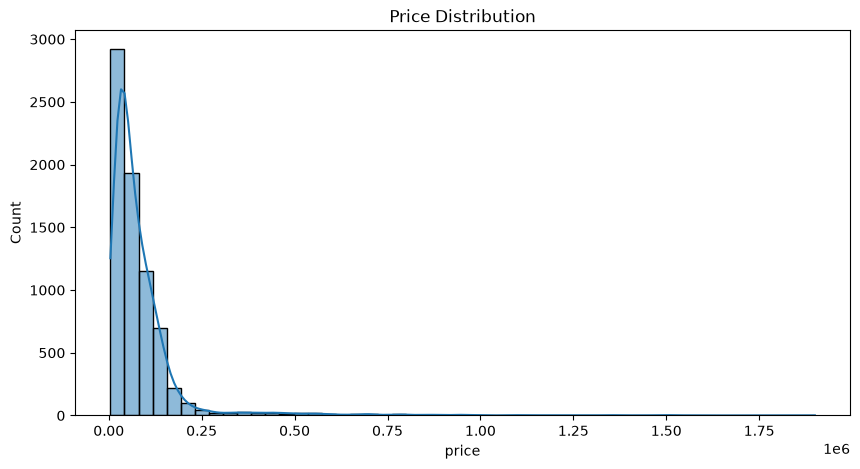

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.show()

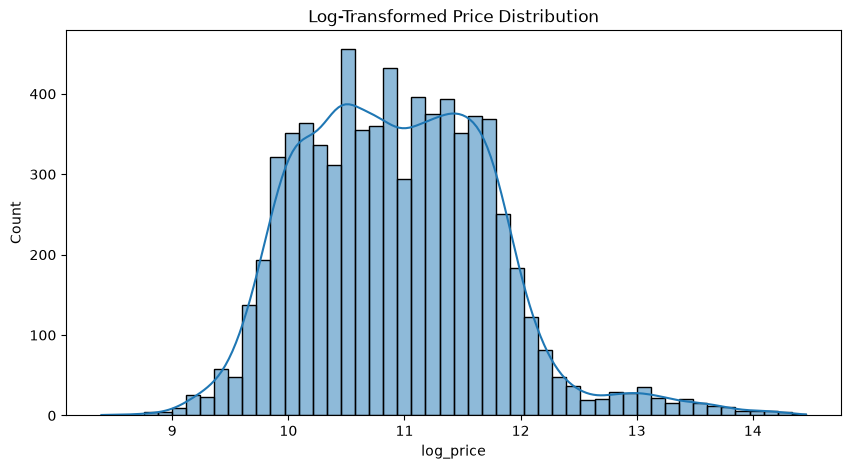

In [14]:
import numpy as np

df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(10,5))
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title('Log-Transformed Price Distribution')
plt.show()

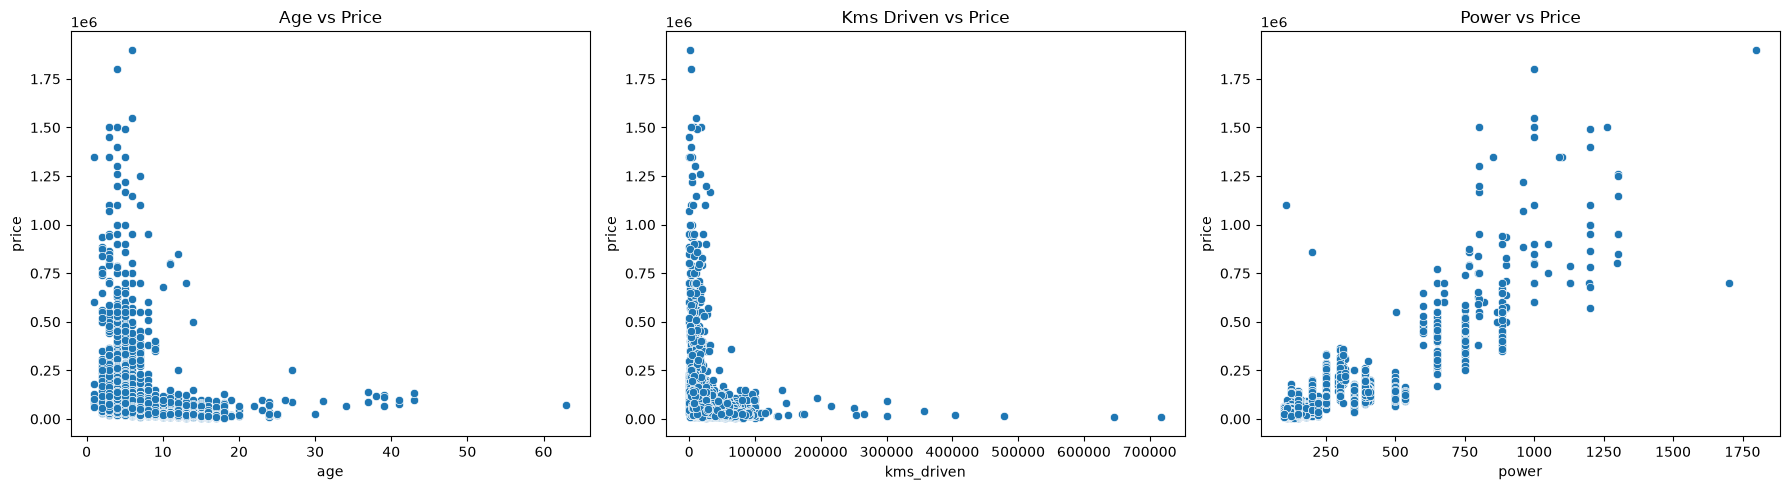

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=df, x='age', y='price', ax=axes[0])
axes[0].set_title('Age vs Price')

sns.scatterplot(data=df, x='kms_driven', y='price', ax=axes[1])
axes[1].set_title('Kms Driven vs Price')

sns.scatterplot(data=df, x='power', y='price', ax=axes[2])
axes[2].set_title('Power vs Price')

plt.tight_layout()
plt.show()

In [16]:
print(df[['price','age','kms_driven','power']].corr()['price'].sort_values(ascending=False))

price         1.000000
power         0.807630
kms_driven   -0.225611
age          -0.248722
Name: price, dtype: float64


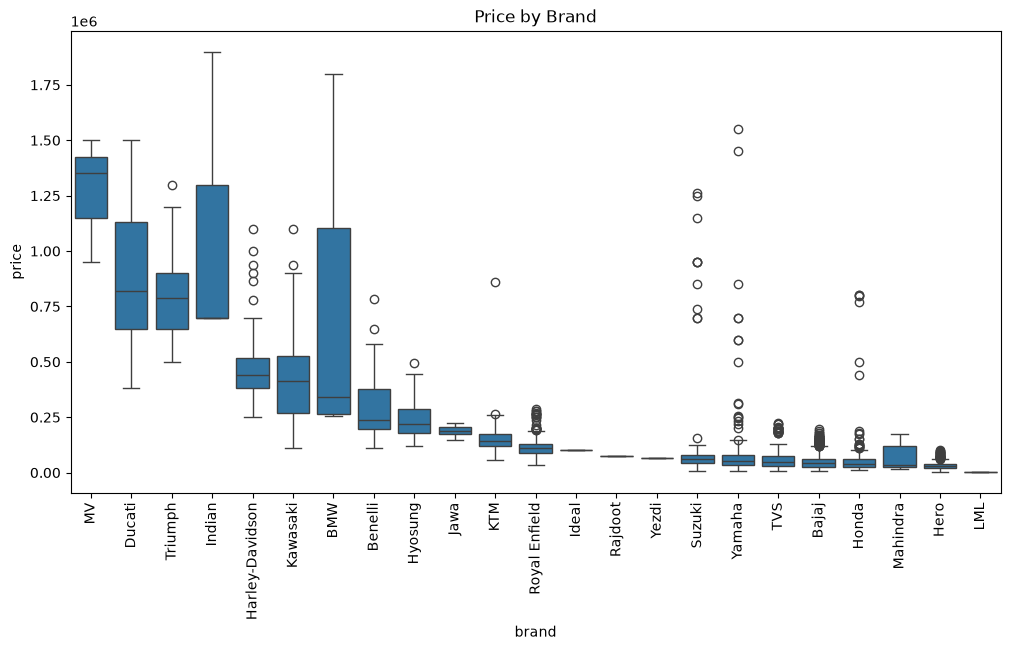

In [17]:
plt.figure(figsize=(12,6))
brand_order = df.groupby('brand')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='brand', y='price', order=brand_order)
plt.xticks(rotation=90)
plt.title('Price by Brand')
plt.show()

In [18]:
print(df['owner'].value_counts())

owner
First Owner             6637
Second Owner             587
Third Owner               84
Fourth Owner Or More      10
Name: count, dtype: int64


In [19]:
owner_map = {
    'First Owner': 0,
    'Second Owner': 1,
    'Third Owner': 2,
    'Fourth Owner Or More': 3
}
df['owner_encoded'] = df['owner'].map(owner_map)
df[['owner', 'owner_encoded']].head()

,owner,owner_encoded
0,First Owner,0
1,First Owner,0
2,First Owner,0
3,First Owner,0
4,First Owner,0


In [20]:
df = pd.get_dummies(df, columns=['brand'], prefix='brand', drop_first=True)
print(df.shape)
df.head()

(7318, 31)


,bike_name,price,city,kms_driven,owner,age,power,log_price,owner_encoded,brand_Bajaj,...,brand_LML,brand_MV,brand_Mahindra,brand_Rajdoot,brand_Royal Enfield,brand_Suzuki,brand_TVS,brand_Triumph,brand_Yamaha,brand_Yezdi
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,10.463132,0,False,...,False,False,False,False,False,False,True,False,False,False
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,11.694422,0,False,...,False,False,False,False,True,False,False,False,False,False
2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,13.304687,0,False,...,False,False,False,False,False,False,False,True,False,False
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,11.082158,0,False,...,False,False,False,False,False,False,True,False,False,False
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,11.289794,0,False,...,False,False,False,False,False,False,False,False,True,False


In [21]:
city_counts = df['city'].value_counts()
print(city_counts.head(20))
print("Cities with only 1 listing:", (city_counts == 1).sum())
print("Cities with 5 or fewer listings:", (city_counts <= 5).sum())

city
Delhi        1425
Bangalore     683
Mumbai        608
Gurgaon       474
Faridabad     463
Pune          394
Jaipur        298
Chennai       287
Ahmedabad     249
Ghaziabad     242
Hyderabad     238
Noida         120
Kolkata        79
Ludhiana       78
Thane          75
Jhansi         62
Lucknow        61
Vadodara       57
Surat          41
Jalandhar      40
Name: count, dtype: int64
Cities with only 1 listing: 216
Cities with 5 or fewer listings: 370


In [22]:
top_cities = city_counts.head(15).index
df['city_grouped'] = df['city'].apply(lambda x: x if x in top_cities else 'Other')
print(df['city_grouped'].value_counts())

city_grouped
Other        1605
Delhi        1425
Bangalore     683
Mumbai        608
Gurgaon       474
Faridabad     463
Pune          394
Jaipur        298
Chennai       287
Ahmedabad     249
Ghaziabad     242
Hyderabad     238
Noida         120
Kolkata        79
Ludhiana       78
Thane          75
Name: count, dtype: int64


In [23]:
df = pd.get_dummies(df, columns=['city_grouped'], prefix='city', drop_first=True)
print(df.shape)

(7318, 46)


In [24]:
df_model = df.drop(columns=['bike_name', 'price', 'city', 'owner'])
print(df_model.shape)
df_model.columns.tolist()

(7318, 42)


['kms_driven',
 'age',
 'power',
 'log_price',
 'owner_encoded',
 'brand_Bajaj',
 'brand_Benelli',
 'brand_Ducati',
 'brand_Harley-Davidson',
 'brand_Hero',
 'brand_Honda',
 'brand_Hyosung',
 'brand_Ideal',
 'brand_Indian',
 'brand_Jawa',
 'brand_KTM',
 'brand_Kawasaki',
 'brand_LML',
 'brand_MV',
 'brand_Mahindra',
 'brand_Rajdoot',
 'brand_Royal Enfield',
 'brand_Suzuki',
 'brand_TVS',
 'brand_Triumph',
 'brand_Yamaha',
 'brand_Yezdi',
 'city_Bangalore',
 'city_Chennai',
 'city_Delhi',
 'city_Faridabad',
 'city_Ghaziabad',
 'city_Gurgaon',
 'city_Hyderabad',
 'city_Jaipur',
 'city_Kolkata',
 'city_Ludhiana',
 'city_Mumbai',
 'city_Noida',
 'city_Other',
 'city_Pune',
 'city_Thane']

In [25]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['log_price'])
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(5854, 41) (1464, 41)


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE (log scale):", mean_absolute_error(y_test, y_pred))
print("RMSE (log scale):", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.8126881984159169
MAE (log scale): 0.23343659510246184
RMSE (log scale): 0.35828998211721585


In [27]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
print("MAE (actual ₹):", mae_actual)

MAE (actual ₹): 32587.659048767873


In [28]:
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
print("MAPE:", mape, "%")

MAPE: 24.118690082892073 %


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_rf))

y_pred_rf_actual = np.expm1(y_pred_rf)
mae_rf = mean_absolute_error(y_test_actual, y_pred_rf_actual)
mape_rf = np.mean(np.abs((y_test_actual - y_pred_rf_actual) / y_test_actual)) * 100

print("MAE (actual ₹):", mae_rf)
print("MAPE:", mape_rf, "%")

R² Score: 0.9193727243887049
MAE (actual ₹): 14065.636089896885
MAPE: 17.239964908703396 %


In [30]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(15))

power                    0.699196
age                      0.196857
kms_driven               0.036956
brand_KTM                0.014134
brand_Bajaj              0.005822
brand_Yamaha             0.005044
brand_Royal Enfield      0.004728
owner_encoded            0.003138
brand_Harley-Davidson    0.003060
city_Delhi               0.002912
city_Faridabad           0.002853
city_Other               0.002586
city_Gurgaon             0.002341
city_Pune                0.002077
city_Bangalore           0.002018
dtype: float64


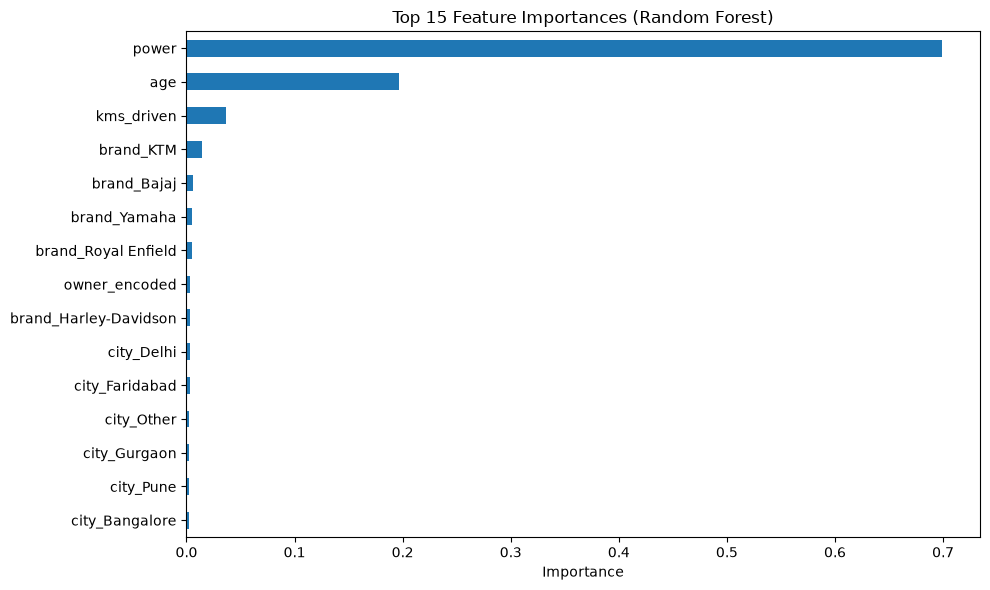

In [31]:
plt.figure(figsize=(10,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_xgb))

y_pred_xgb_actual = np.expm1(y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb_actual)
mape_xgb = np.mean(np.abs((y_test_actual - y_pred_xgb_actual) / y_test_actual)) * 100

print("MAE (actual ₹):", mae_xgb)
print("MAPE:", mape_xgb, "%")

R² Score: 0.9292215518436698
MAE (actual ₹): 13386.719363686818
MAPE: 15.99069491284727 %


In [33]:
import joblib

joblib.dump(xgb, '../models/bike_price_model.pkl')
joblib.dump(X_train.columns.tolist(), '../models/model_columns.pkl')

print("Model saved successfully")

Model saved successfully


In [34]:
from xgboost import XGBRegressor

# Lower bound model (10th percentile)
xgb_lower = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.1, n_estimators=100, random_state=42)
xgb_lower.fit(X_train, y_train)

# Upper bound model (90th percentile)
xgb_upper = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.9, n_estimators=100, random_state=42)
xgb_upper.fit(X_train, y_train)

print("Both quantile models trained")

Both quantile models trained


In [35]:
lower_pred = xgb_lower.predict(X_test)
upper_pred = xgb_upper.predict(X_test)

# Convert back to actual rupees
lower_pred_actual = np.expm1(lower_pred)
upper_pred_actual = np.expm1(upper_pred)

# Quick sanity check on a few rows
comparison = pd.DataFrame({
    'actual_price': y_test_actual.values,
    'predicted_lower': lower_pred_actual,
    'predicted_upper': upper_pred_actual
})
comparison.head(10)

,actual_price,predicted_lower,predicted_upper
0,52000.0,52901.929688,67606.828125
1,102850.0,105615.484375,158142.812500
2,20400.0,18587.960938,25826.964844
3,137300.0,92741.046875,129428.078125
4,85000.0,81827.882812,111728.234375
5,73000.0,42019.628906,89924.203125
6,39500.0,33849.867188,37588.324219
7,140000.0,114566.460938,178640.250000
8,32500.0,23326.658203,34084.921875
9,92000.0,74726.070312,101595.343750


In [36]:
within_range = ((comparison['actual_price'] >= comparison['predicted_lower']) & 
                 (comparison['actual_price'] <= comparison['predicted_upper']))
print(f"% of listings within predicted range: {within_range.mean() * 100:.1f}%")

% of listings within predicted range: 73.4%


In [37]:
def classify_listing(row):
    if row['actual_price'] < row['predicted_lower']:
        return 'Underpriced (Good Deal)'
    elif row['actual_price'] > row['predicted_upper']:
        return 'Overpriced'
    else:
        return 'Fair Price'

comparison['verdict'] = comparison.apply(classify_listing, axis=1)
print(comparison['verdict'].value_counts())
comparison.head(10)

verdict
Fair Price                 1074
Underpriced (Good Deal)     205
Overpriced                  185
Name: count, dtype: int64


,actual_price,predicted_lower,predicted_upper,verdict
0,52000.0,52901.929688,67606.828125,Underpriced (Good Deal)
1,102850.0,105615.484375,158142.812500,Underpriced (Good Deal)
2,20400.0,18587.960938,25826.964844,Fair Price
3,137300.0,92741.046875,129428.078125,Overpriced
4,85000.0,81827.882812,111728.234375,Fair Price
5,73000.0,42019.628906,89924.203125,Fair Price
6,39500.0,33849.867188,37588.324219,Overpriced
7,140000.0,114566.460938,178640.250000,Fair Price
8,32500.0,23326.658203,34084.921875,Fair Price
9,92000.0,74726.070312,101595.343750,Fair Price


In [38]:
joblib.dump(xgb_lower, '../models/bike_price_model_lower.pkl')
joblib.dump(xgb_upper, '../models/bike_price_model_upper.pkl')
print("Quantile models saved")

Quantile models saved
